<a href="https://colab.research.google.com/github/dhruv10829-dot/ML-Lab-Work/blob/main/lab_09_ml_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ML Lab – Experiment 9
## Random Forest Classification
### Dataset: Cervical Cancer Risk Factors

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv('/content/risk_factors_cervical_cancer.csv')
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [4]:
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric)
df.fillna(df.mean(), inplace=True)

In [5]:
X = df.drop(['Biopsy'], axis=1)
y = df['Biopsy']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
y_pred = rf.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.936046511627907

Confusion Matrix:
 [[156   5]
 [  6   5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       161
           1       0.50      0.45      0.48        11

    accuracy                           0.94       172
   macro avg       0.73      0.71      0.72       172
weighted avg       0.93      0.94      0.93       172



In [10]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)
importance

,Feature,Importance
33,Schiller,0.295592
32,Hinselmann,0.096288
0,Age,0.093572
2,First sexual intercourse,0.075097
34,Citology,0.061981
8,Hormonal Contraceptives (years),0.061709
3,Num of pregnancies,0.049562
1,Number of sexual partners,0.048629
5,Smokes (years),0.018783
7,Hormonal Contraceptives,0.018182


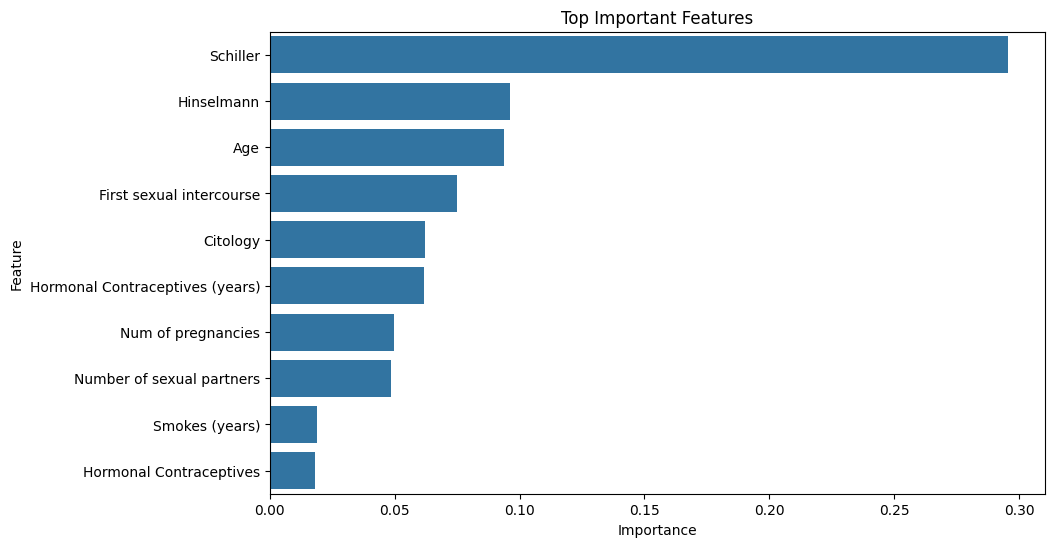

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title("Top Important Features")
plt.show()